#  Repressilator: A Synthetic Oscillator

The repressilator is a synthetic genetic circuit designed to produce oscillatory behavior in gene expression. It was first introduced by Elowitz and Leibler in 2000 as a demonstration of how synthetic biology can be used to engineer predictable and tunable behaviors in living cells.

The repressilator consists of three genes arranged in a cyclic inhibitory network. Each gene produces a protein that represses the expression of the next gene in the cycle. This feedback loop creates oscillations in the concentrations of the mRNA and proteins associated with each gene.


In [1]:
%reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Dynamics of the Repressilator

The dynamics of the repressilator can be described using a system of ordinary differential equations. These equations capture the rates of change of mRNA and protein concentrations for each gene in the network

- $m_1 , m_2 , m_3 $: mRNA concentrations for the three genes
- $p_1 (lacl), p_2 (tetR), p_3, (cl)$: Protein concentrations for proteins produced by the genes.

### mRNA Dynamics


$\frac{dm_1}{dt} = -m_1 + \frac{\alpha}{1 + p_3^n} + \alpha_0$

$\frac{dm_2}{dt} = -m_2 + \frac{\alpha}{1 + p_1^n} + \alpha_0$

$\frac{dm_3}{dt} = -m_3 + \frac{\alpha}{1 + p_2^n} + \alpha_0$


### Protein Dynamics


$\frac{dp_1}{dt} = -\beta (p_1 - m_1)$

$\frac{dp_2}{dt} = -\beta (p_2 - m_2)$

$\frac{dp_3}{dt} = -\beta (p_3 - m_3)$

### Parameter Sensitivity
The behavior of the repressilator depends on key parameters:
- Maximum transcription rate ($\alpha$): Controls the amplitude of oscillations.
- Basal transcription rate ($\alpha_0$): Ensures non-zero expression levels.
- Protein degradation rate ($\beta$): Affects the period of oscillations.
- Hill coefficient ($n$): Determines the steepness of repression.

By varying these parameters, we can observe how the repressilator's dynamics change.

In [2]:
# Definitions and Set Variables

alpha = 10.0      # Initial Value = 10.0
alpha0 = 0.1      # Initial Value = 0.1
beta = 1.0        # Initial Value = 1.0
n = 2.0           # Initial Value = 2.0

def repressilator(t, y):
    
    # unpack y = [m1, m2, m3, p1, p2, p3]
    m1, m2, m3, p1, p2, p3 = y

    # mRNA Dynamics
    dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0
    dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0
    dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0

    # Protein Dynamics
    dp1_dt = -beta * (p1 - m1)
    dp2_dt = -beta * (p2 - m2)
    dp3_dt = -beta * (p3 - m3)

    deltas = [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]
    
    return deltas

# Simulating the Repressilator

In this notebook, we simulate the repressilator using the `solve_ivp` function from the `scipy.integrate` library. The initial conditions for mRNA and protein concentrations are randomly generated.

The results are visualized as time-series plots showing the oscillations in mRNA and protein concentrations. These oscillations demonstrate the periodic behavior of the repressilator circuit.


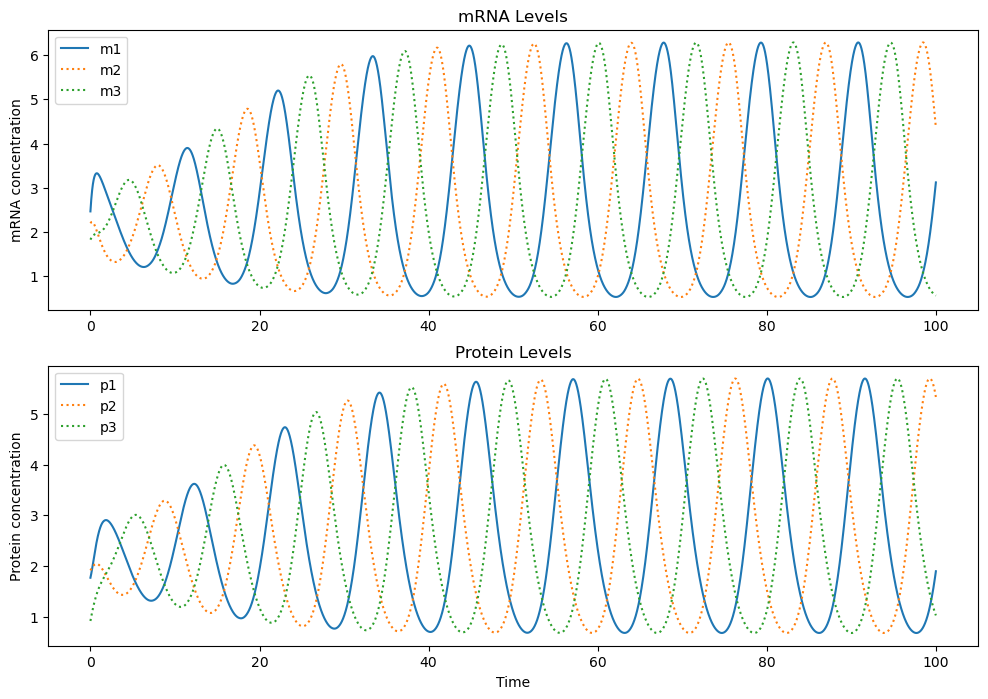

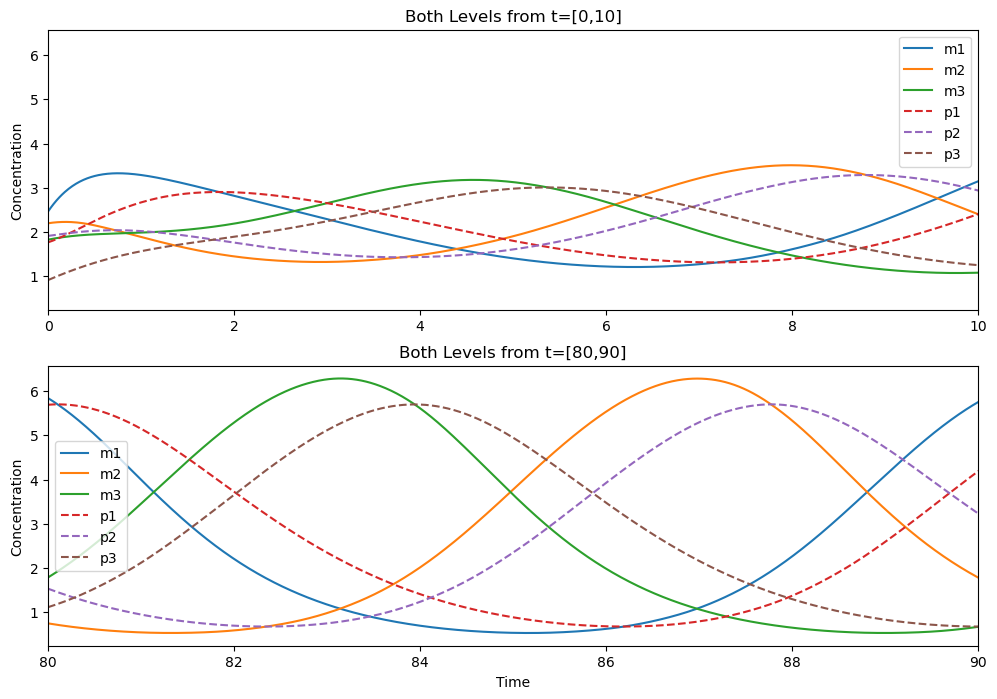

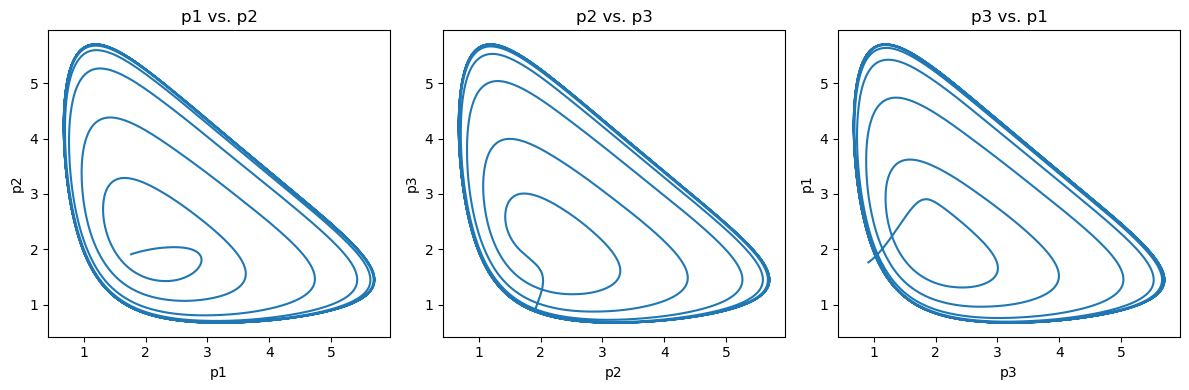

In [3]:
# Set initial Conditions
y0 = np.random.uniform(0, 3, size=6)  # Generates 6 random values for [m1, m2, m3, p1, p2, p3]
t = np.linspace(0,100,10000)

# Solving the System of ODEs
solution = solve_ivp(repressilator, [t[0], t[-1]], y0, t_eval=t)

# Create Protein and mRNA Subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot mRNA dynamics
axs[0].plot(solution.t, solution.y[0], label="m1")
axs[0].plot(solution.t, solution.y[1], label="m2", ls=":")
axs[0].plot(solution.t, solution.y[2], label="m3", ls=":")
axs[0].set_ylabel("mRNA concentration")
axs[0].set_title("mRNA Levels")
axs[0].legend()

# Plot protein dynamics
axs[1].plot(solution.t, solution.y[3], label="p1")
axs[1].plot(solution.t, solution.y[4], label="p2", ls=":")
axs[1].plot(solution.t, solution.y[5], label="p3", ls=":")
axs[1].set_ylabel("Protein concentration")
axs[1].set_xlabel("Time")
axs[1].set_title("Protein Levels")
axs[1].legend()

# Create Subplots to show detailed time windows

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot All for early time window t=[2,4]
axs[0].plot(solution.t, solution.y[0], label="m1")
axs[0].plot(solution.t, solution.y[1], label="m2")
axs[0].plot(solution.t, solution.y[2], label="m3")
axs[0].plot(solution.t, solution.y[3], label="p1", ls="--")
axs[0].plot(solution.t, solution.y[4], label="p2", ls="--")
axs[0].plot(solution.t, solution.y[5], label="p3", ls="--")
axs[0].set_xlim(0,10)
axs[0].set_ylabel("Concentration")
axs[0].set_title("Both Levels from t=[0,10]")
axs[0].legend()

# Plot All for late time window t=[16,18]
axs[1].plot(solution.t, solution.y[0], label="m1")
axs[1].plot(solution.t, solution.y[1], label="m2")
axs[1].plot(solution.t, solution.y[2], label="m3")
axs[1].plot(solution.t, solution.y[3], label="p1", ls="--")
axs[1].plot(solution.t, solution.y[4], label="p2", ls="--")
axs[1].plot(solution.t, solution.y[5], label="p3", ls="--")
axs[1].set_xlim(80,90)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Concentration")
axs[1].set_title("Both Levels from t=[80,90]")
axs[1].legend()

# Phase Plots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# p1 vs. p2
axs[0].plot(solution.y[3], solution.y[4])
axs[0].set_xlabel("p1")
axs[0].set_ylabel("p2")
axs[0].set_title("p1 vs. p2")

# p2 vs. p3
axs[1].plot(solution.y[4], solution.y[5])
axs[1].set_xlabel("p2")
axs[1].set_ylabel("p3")
axs[1].set_title("p2 vs. p3")

# p3 vs. p1
axs[2].plot(solution.y[5], solution.y[3])
axs[2].set_xlabel("p3")
axs[2].set_ylabel("p1")
axs[2].set_title("p3 vs. p1")

# Display plots
plt.tight_layout()
plt.show()


# Noise and Stochasticity

Biological systems are inherently noisy due to random fluctuations in molecular interactions, such as transcription, translation, and degradation processes. In the context of the repressilator, noise can affect the amplitude, period, and stability of oscillations.

Adding noise to the repressilator model provides a more realistic simulation of how the circuit behaves in living cells. For example, noise can cause variability in the timing of oscillations, leading to desynchronization between cells in a population. Despite this variability, the repressilator's design ensures that oscillations persist.

By incorporating noise into the mathematical model, we can explore how the repressilator responds to fluctuations and identify conditions under which oscillations remain stable.

In [5]:
def noisy_repressilator(t, y):
    
    # Unpack y = [m1, m2, m3, p1, p2, p3]
    m1, m2, m3, p1, p2, p3 = y

    # Generate Noise
    noise = np.random.normal(0, 0.05, size=6)

    # mRNA Dynamics with Noise
    dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0 + noise[0]
    dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0 + noise[1]
    dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0 + noise[2]

    # Protein Dynamics with Noise
    dp1_dt = -beta * (p1 - m1) + noise[3]
    dp2_dt = -beta * (p2 - m2) + noise[4]
    dp3_dt = -beta * (p3 - m3) + noise[5] 

    deltas = [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]

    return deltas

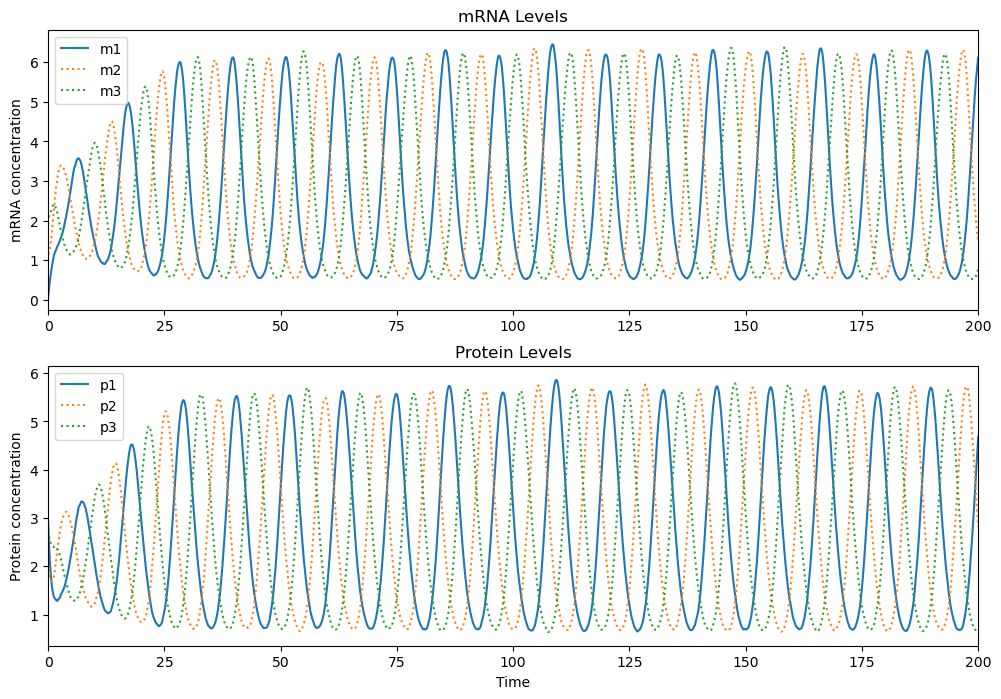

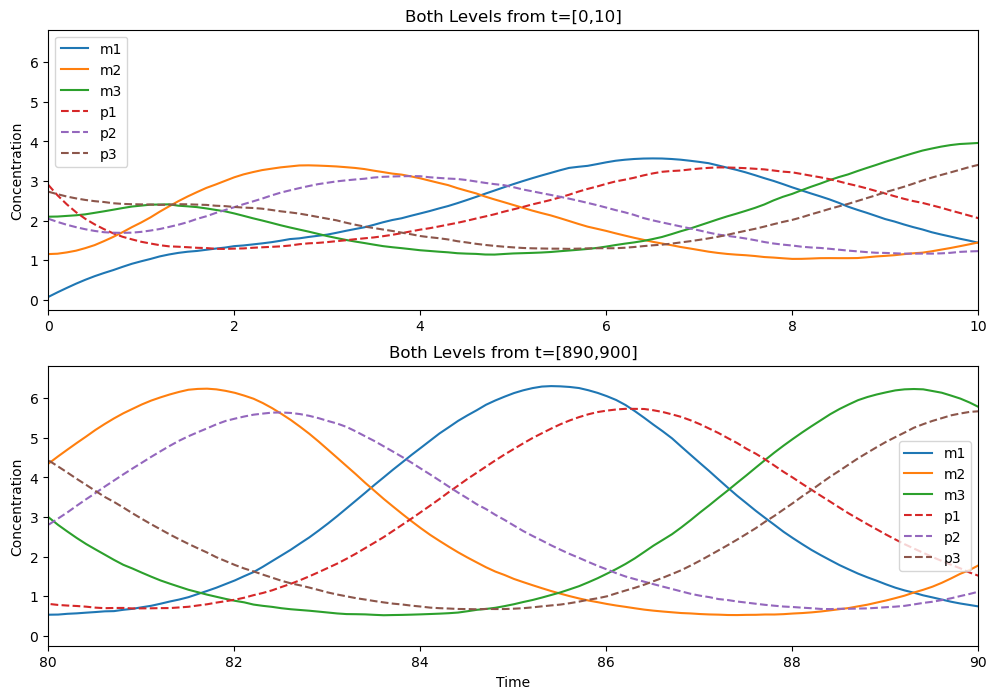

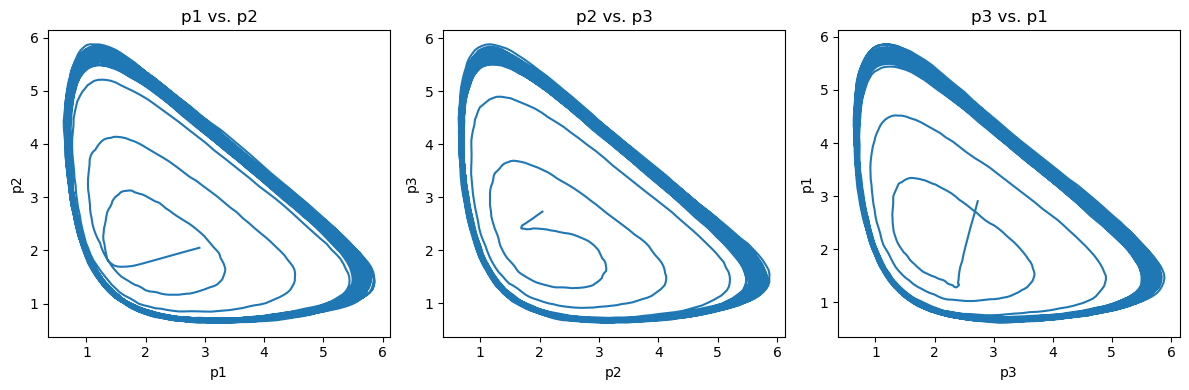

In [6]:
# Set initial Conditions
y0 = np.random.uniform(0, 3, size=6)  # Generates 6 random values for [m1, m2, m3, p1, p2, p3]
t = np.linspace(0,1000,10000)

# Solving the System of ODEs
solution = solve_ivp(noisy_repressilator, [t[0], t[-1]], y0, t_eval=t)

# Create Protein and mRNA Subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot mRNA dynamics
axs[0].plot(solution.t, solution.y[0], label="m1")
axs[0].plot(solution.t, solution.y[1], label="m2", ls=":")
axs[0].plot(solution.t, solution.y[2], label="m3", ls=":")
axs[0].set_xlim(0,200)
axs[0].set_ylabel("mRNA concentration")
axs[0].set_title("mRNA Levels")
axs[0].legend()

# Plot protein dynamics
axs[1].plot(solution.t, solution.y[3], label="p1")
axs[1].plot(solution.t, solution.y[4], label="p2", ls=":")
axs[1].plot(solution.t, solution.y[5], label="p3", ls=":")
axs[1].set_xlim(0,200)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Protein concentration")
axs[1].set_title("Protein Levels")
axs[1].legend()

# Create Subplots to Show Detailed Time Windows

fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot All for Early Time Window t=[2,4]
axs[0].plot(solution.t, solution.y[0], label="m1")
axs[0].plot(solution.t, solution.y[1], label="m2")
axs[0].plot(solution.t, solution.y[2], label="m3")
axs[0].plot(solution.t, solution.y[3], label="p1", ls="--")
axs[0].plot(solution.t, solution.y[4], label="p2", ls="--")
axs[0].plot(solution.t, solution.y[5], label="p3", ls="--")
axs[0].set_xlim(0,10)
axs[0].set_ylabel("Concentration")
axs[0].set_title("Both Levels from t=[0,10]")
axs[0].legend()

# Plot All for Late Time Window t=[16,18]
axs[1].plot(solution.t, solution.y[0], label="m1")
axs[1].plot(solution.t, solution.y[1], label="m2")
axs[1].plot(solution.t, solution.y[2], label="m3")
axs[1].plot(solution.t, solution.y[3], label="p1", ls="--")
axs[1].plot(solution.t, solution.y[4], label="p2", ls="--")
axs[1].plot(solution.t, solution.y[5], label="p3", ls="--")
axs[1].set_xlim(80,90)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Concentration")
axs[1].set_title("Both Levels from t=[890,900]")
axs[1].legend()

# Phase Plots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# p1 vs. p2
axs[0].plot(solution.y[3], solution.y[4])
axs[0].set_xlabel("p1")
axs[0].set_ylabel("p2")
axs[0].set_title("p1 vs. p2")

# p2 vs. p3
axs[1].plot(solution.y[4], solution.y[5])
axs[1].set_xlabel("p2")
axs[1].set_ylabel("p3")
axs[1].set_title("p2 vs. p3")

# p3 vs. p1
axs[2].plot(solution.y[5], solution.y[3])
axs[2].set_xlabel("p3")
axs[2].set_ylabel("p1")
axs[2].set_title("p3 vs. p1")

# Display plots
plt.tight_layout()
plt.show()
